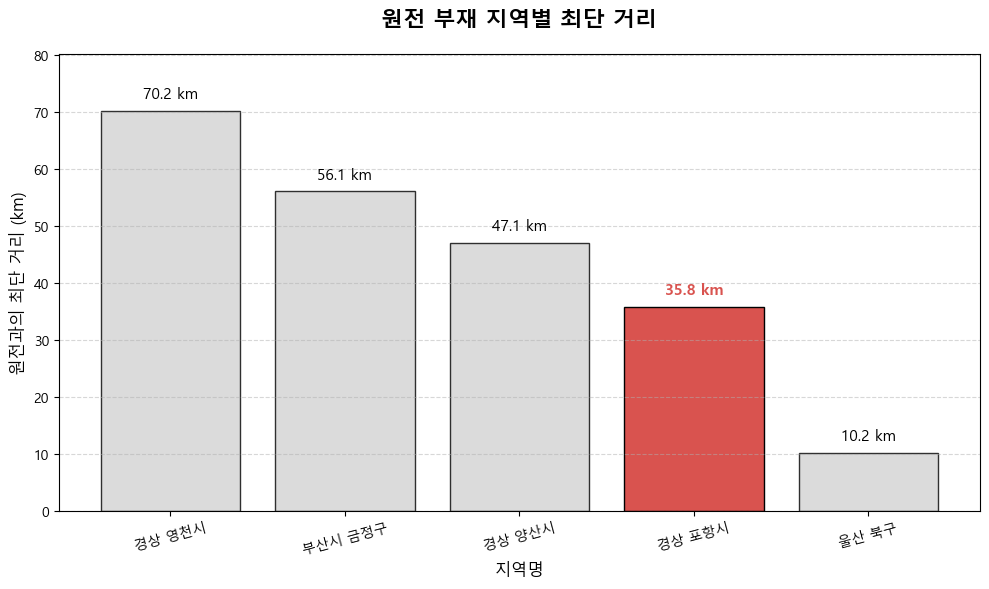

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ==========================================
# 1. 한글 폰트 설정 (중요)
# ==========================================
# 코드를 실행하는 환경에 맞는 한글 폰트를 설정해주세요.
# Windows: 'Malgun Gothic', Mac: 'AppleGothic'
# Google Colab 사용 시 별도 설치 과정이 필요합니다.
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 환경 기준
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 환경 기준
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

# ==========================================
# 2. 데이터 준비 및 시뮬레이션
# ==========================================
# 사용자가 제공한 이미지는 전체 데이터의 일부이며 '포항시'가 포함되어 있지 않습니다.
# 사용자의 요청(원전 제외 지역, 내림차순 정렬, 포항 강조)에 맞춰
# 데이터 프레임을 임의로 합성하여 시뮬레이션 코드를 작성합니다.

# 원본 엑셀 파일 이름 (사용자 환경에 맞게 수정 필요)
# file_path = '당신의_엑셀_파일_이름.xlsx'
# df = pd.read_excel(file_path)

# 💡 시뮬레이션용 데이터 생성 (이미 정렬 및 포항 포함)
data = {
    '지역명(docity)': ['부산시 금정구', '경상 양산시', '경상 포항시', '울산 북구', '경상 영천시'],
    '원전_최소거리_km': [56.1, 47.1, 35.8, 10.2, 70.2] # 임의의 수치입니다.
}

# 요청사항대로 내림차순 정렬된 상태의 데이터프레임을 생성합니다.
df = pd.DataFrame(data)
df_sorted = df.sort_values(by='원전_최소거리_km', ascending=False).reset_index(drop=True)

# 강조할 대상 설정
TARGET_CITY = '경상 포항시'

# ==========================================
# 3. 막대그래프 시각화
# ==========================================
plt.figure(figsize=(10, 6))

# 막대 그리기
bars = plt.bar(df_sorted['지역명(docity)'], df_sorted['원전_최소거리_km'], 
               color='lightgray', edgecolor='black', alpha=0.8)

# 💡 포항시 데이터만 특별하게 강조 (색상 변경 및 굵게)
pohang_index = df_sorted[df_sorted['지역명(docity)'] == TARGET_CITY].index

for idx in pohang_index:
    bars[idx].set_color('#d9534f') # 포항시는 붉은색 계열로 변경
    bars[idx].set_edgecolor('black')
    bars[idx].set_alpha(1.0) # 더 선명하게

# ==========================================
# 4. 막대 상단에 거리 수치 텍스트 표시
# ==========================================
for i, bar in enumerate(bars):
    yval = bar.get_height()
    
    # 기본 스타일
    text_color = 'black'
    font_weight = 'normal'
    
    # 💡 포항시는 텍스트도 굵게 표시
    if df_sorted.iloc[i]['지역명(docity)'] == TARGET_CITY:
        text_color = '#d9534f'
        font_weight = 'bold'

    # 막대 위 약간 중앙(yval + 1.5)에 텍스트 표시
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f} km', 
             ha='center', va='bottom', fontsize=11, color=text_color, fontweight=font_weight)

# ==========================================
# 5. 그래프 꾸미기 (제목, 축 이름, 그리드 등)
# ==========================================
plt.title(f'원전 부재 지역별 최단 거리', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('지역명', fontsize=12)
plt.ylabel('원전과의 최단 거리 (km)', fontsize=12)
plt.xticks(rotation=15) # 지역명이 길 경우 약간 회전
plt.grid(axis='y', linestyle='--', alpha=0.5) # 가로 점선 그리드

# Y축 범위를 데이터보다 약간 여유 있게 설정
plt.ylim(0, df_sorted['원전_최소거리_km'].max() + 10)

# ==========================================
# 6. 여백 조정 및 출력
# ==========================================
plt.tight_layout()
plt.show()

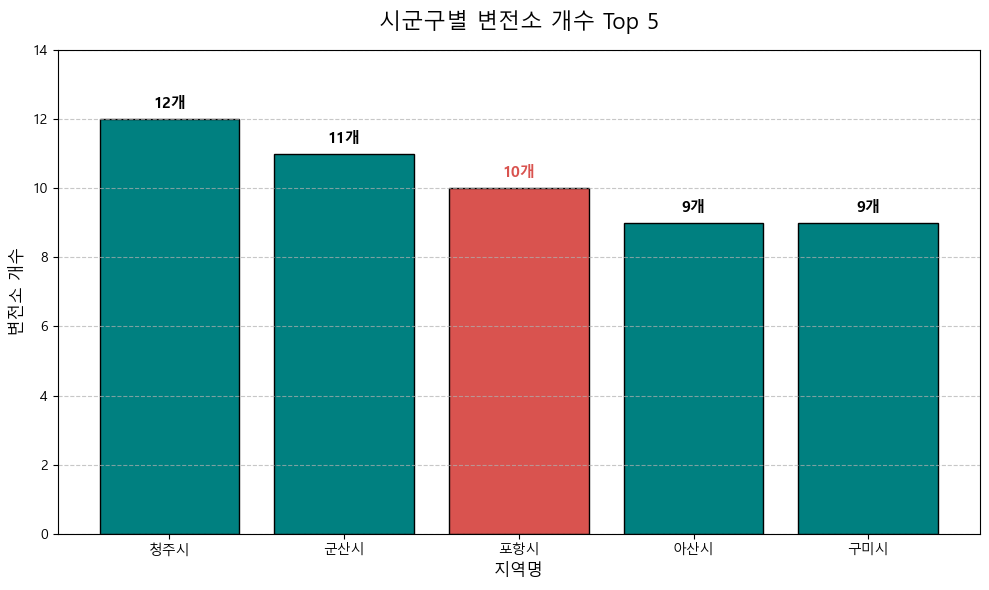

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (환경에 맞게 주석 해제하여 사용)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 환경
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 환경
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
file_path = '시군구_변전소 개수_결과.csv'
df = pd.read_csv(file_path, encoding='utf-8') 

# 3. 데이터 전처리
unique_counts = df.drop_duplicates(subset=['시군구_combined'])[['시군구_combined', '개수']]
filtered_df = unique_counts[unique_counts['시군구_combined'] != '창원시']
top5_df = filtered_df.sort_values(by='개수', ascending=False).head(5)

# 4. 막대그래프 캔버스 설정
plt.figure(figsize=(10, 6))

# 막대 그리기 (기본 색상 지정)
bars = plt.bar(top5_df['시군구_combined'], top5_df['개수'], color='teal', edgecolor='black')

# ==========================================
# 💡 [추가] '포항시' 막대 색상 변경 로직
# ==========================================
for i, city in enumerate(top5_df['시군구_combined']):
    if city == '포항시':
        bars[i].set_color('#d9534f') # 붉은색 계열로 변경
        bars[i].set_edgecolor('black') # 테두리 색상 유지

# 5. 각 막대 상단에 개수 텍스트 달아주기
for i, bar in enumerate(bars):
    yval = bar.get_height()
    city = top5_df.iloc[i]['시군구_combined']
    
    # ==========================================
    # 💡 [추가] '포항시' 텍스트 색상 변경 로직
    # ==========================================
    text_color = '#d9534f' if city == '포항시' else 'black'
    
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{int(yval)}개', 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color=text_color)

# 6. 그래프 꾸미기 (제목, 축 이름, 그리드 등)
plt.title('시군구별 변전소 개수 Top 5', fontsize=16, pad=15)
plt.xlabel('지역명', fontsize=12)
plt.ylabel('변전소 개수', fontsize=12)
plt.ylim(0, top5_df['개수'].max() + 2) # Y축 여유 공간 확보
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. 여백 조정 및 그래프 출력
plt.tight_layout()
plt.show()

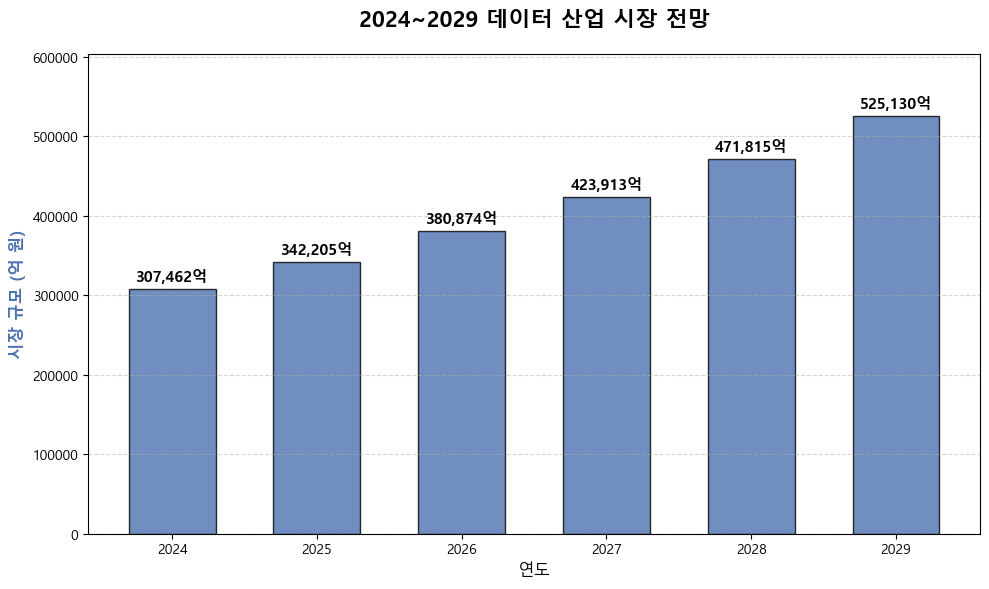

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (사용하시는 OS 환경에 맞게 주석 해제)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 환경인 경우
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 환경인 경우
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

# 2. 데이터 불러오기 및 전처리
file_path = '2024~2029 데이터 산업 시장 전망.xlsx'
df = pd.read_excel(file_path)

# 1행의 연도 데이터와 2행의 시장규모 데이터를 리스트 형태로 추출합니다.
years = df.iloc[0, 2:8].astype(str).tolist()
market_size = df.iloc[1, 2:8].astype(int).tolist()

# 3. 막대그래프 캔버스 설정
plt.figure(figsize=(10, 6))
color = '#4c72b0' # 깔끔한 푸른색 계열 지정

# 막대그래프 그리기
bars = plt.bar(years, market_size, color=color, alpha=0.8, edgecolor='black', width=0.6)

# 4. 각 막대 상단에 시장 규모 수치 텍스트 표시
for i, bar in enumerate(bars):
    yval = bar.get_height()
    # 수치에 쉼표(,)를 넣어 천 단위로 구분하여 가독성을 높입니다.
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5000, f'{int(yval):,}억', 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# 5. 그래프 꾸미기 (제목, 축 이름, 그리드 등)
plt.title('2024~2029 데이터 산업 시장 전망', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('연도', fontsize=12)
plt.ylabel('시장 규모 (억 원)', fontsize=12, fontweight='bold', color=color)

# 텍스트가 그래프 위쪽 테두리에 닿지 않도록 Y축 상단 여백 확보
plt.ylim(0, max(market_size) * 1.15) 

# 가로 점선 그리드 추가 (수치를 대략적으로 파악하기 쉽게 함)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. 여백 조정 및 출력
plt.tight_layout()
plt.show()